<a href="https://colab.research.google.com/github/NageshNaikwade/PDS-Practicals/blob/main/ex7_B12_Nagesh_Naikwade_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Nagesh Sunil Naikwade
Branch: AI&DS
Roll No.: SY-B12
Batch: SY-B1


# AIM:
Implement and analyze various probability distributions in Python, including Binomial, Poisson, and Normal distributions.

# THEORY:
**1. What is the difference between Binomial, Poisson, and Normal distributions?**

The Binomial, Poisson, and Normal distributions differ mainly in their nature and application. The Binomial distribution is a discrete distribution used when there is a fixed number of trials, each having only two possible outcomes (success or failure), with a constant probability of success. In contrast, the Poisson distribution is also discrete but is used to model the number of events occurring in a fixed interval of time or space, where events happen independently and at a constant average rate. The Normal distribution, however, is continuous and represents data that is symmetrically distributed around a mean, forming a bell-shaped curve. While Binomial deals with fixed trials and Poisson with event frequency, the Normal distribution is used for continuous data and natural variations.


**2. What is the real-world significance of the Poisson distribution?**

The Poisson distribution is highly significant in real-world scenarios where we need to model the occurrence of rare and random events over a specific interval. It is widely used in fields such as telecommunications to estimate the number of calls received per minute, in traffic management to predict accidents at a particular location, and in manufacturing to count the number of defects in a production process. It is also useful in healthcare for modeling the spread of diseases or the number of patient arrivals in a hospital. Its importance lies in helping organizations predict probabilities, manage risks, and make informed decisions in situations involving uncertainty and randomness.


**3. What is the Central Limit Theorem and how does it relate to Normal distribution?**

The Central Limit Theorem (CLT) states that when we take sufficiently large samples from any population, regardless of its original distribution, the distribution of the sample means will tend to follow a Normal distribution. This means that even if the population data is skewed or irregular, the averages of repeated samples will form a bell-shaped curve as the sample size increases. The theorem is important because it allows statisticians to use Normal distribution-based methods for analysis, even when the original data is not normally distributed. Thus, CLT acts as a bridge connecting different types of distributions to the Normal distribution.

**4. Why is Normal distribution widely used in machine learning and statistics?**

The Normal distribution is widely used in machine learning and statistics because many real-world phenomena naturally follow a pattern that closely resembles it, such as heights, weights, and test scores. Its symmetrical bell-shaped form makes it mathematically convenient and easy to analyze. Additionally, due to the Central Limit Theorem, many statistical methods rely on the assumption of normality, even when the original data is not perfectly normal. In machine learning, it is used in algorithms for probability estimation, error modeling, and data normalization. Its simplicity and strong theoretical foundation make it a fundamental tool in data analysis and predictive modeling.


**5. What is skewness in distributions and which distributions exhibit it?**

Skewness refers to the measure of asymmetry in a probability distribution. When a distribution is not evenly balanced around its mean, it is said to be skewed. A positively skewed distribution has a longer tail on the right side, indicating that most values are concentrated on the left, while a negatively skewed distribution has a longer tail on the left side, with most values on the right. Among common distributions, the Poisson distribution is typically positively skewed, especially when the average rate is low, and the Binomial distribution can be either positively or negatively skewed depending on the probability of success. The Normal distribution, however, is perfectly symmetrical and has zero skewness.

Saving job_salary_prediction_dataset.csv to job_salary_prediction_dataset.csv
✅ Dataset Loaded Successfully!
            job_title  experience_years education_level  skills_count  \
0         AI Engineer                10        Bachelor             2   
1        Data Analyst                 5        Bachelor            17   
2  Frontend Developer                18             PhD             4   
3    Business Analyst                19             PhD            13   
4     Product Manager                15        Bachelor             7   

        industry company_size   location remote_work  certifications  salary  
0     Healthcare       Medium      India      Hybrid               2  109413  
1        Telecom        Small  Australia          No               0   93764  
2          Media       Medium  Singapore          No               1  148123  
3         Retail       Medium     Canada         Yes               0  189123  
4  Manufacturing        Large     Sweden         Yes     

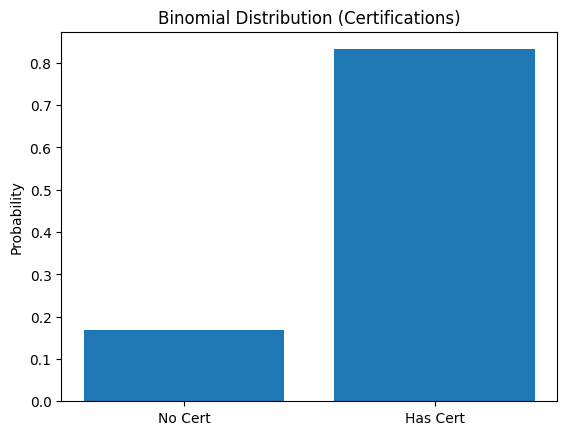


📊 Poisson Distribution


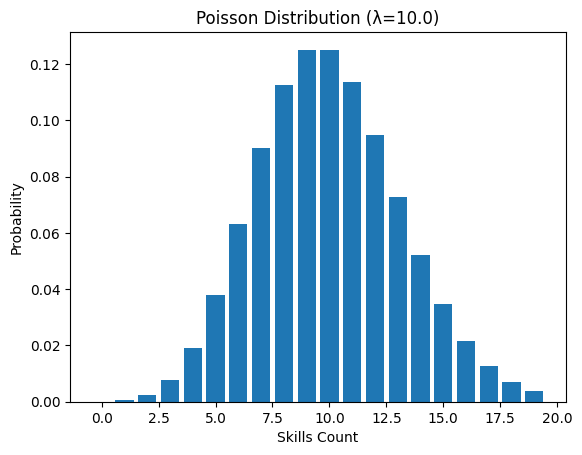


📊 Normal Distribution


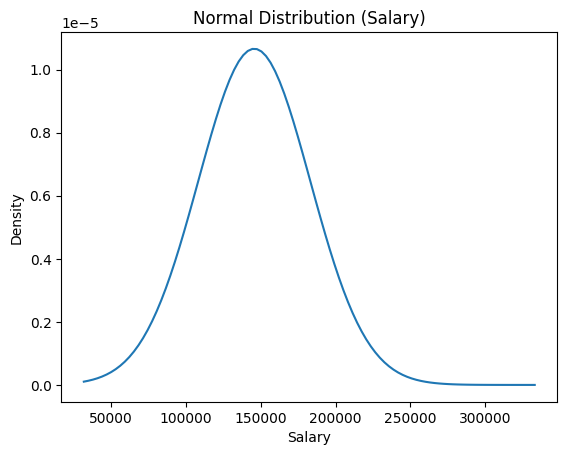

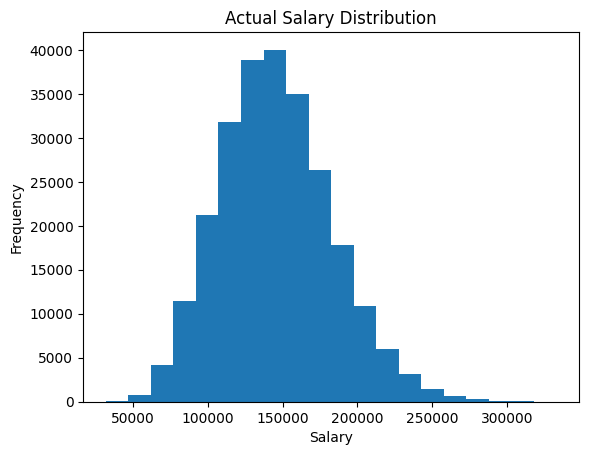

In [ ]:
# -------------------------------
# 1. IMPORT LIBRARIES
# -------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson, norm

# -------------------------------
# 2. UPLOAD CSV FILE
# -------------------------------
from google.colab import files
uploaded = files.upload()

# Get uploaded file name automatically
file_name = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(file_name)

print("✅ Dataset Loaded Successfully!")
print(df.head())


# -------------------------------
# 3. CHECK COLUMNS (IMPORTANT)
# -------------------------------
print("\nAvailable Columns:", df.columns)


# -------------------------------
# 4. HANDLE COLUMN NAMES SAFELY
# (Modify if needed based on your dataset)
# -------------------------------
# Try to auto-detect useful columns
salary_col = None
skills_col = None
cert_col = None

for col in df.columns:
    if "salary" in col.lower():
        salary_col = col
    elif "skill" in col.lower():
        skills_col = col
    elif "cert" in col.lower():
        cert_col = col

# If not found, fallback manually (EDIT if needed)
if salary_col is None:
    salary_col = df.columns[-1]

if skills_col is None:
    skills_col = df.select_dtypes(include=np.number).columns[0]

if cert_col is None:
    cert_col = df.select_dtypes(include=np.number).columns[1]

print(f"\nUsing Columns → Salary: {salary_col}, Skills: {skills_col}, Certifications: {cert_col}")


# -------------------------------
# 5. BINOMIAL DISTRIBUTION
# -------------------------------
print("\n📊 Binomial Distribution")

cert_data = df[cert_col]
p = np.mean(cert_data > 0)

x = np.arange(0, 2)
binomial_pmf = binom.pmf(x, 1, p)

plt.figure()
plt.bar(['No Cert', 'Has Cert'], binomial_pmf)
plt.title("Binomial Distribution (Certifications)")
plt.ylabel("Probability")
plt.show()


# -------------------------------
# 6. POISSON DISTRIBUTION
# -------------------------------
print("\n📊 Poisson Distribution")

skills = df[skills_col]
lam = np.mean(skills)

x = np.arange(0, int(max(skills)) + 1)
poisson_pmf = poisson.pmf(x, lam)

plt.figure()
plt.bar(x, poisson_pmf)
plt.title(f"Poisson Distribution (λ={round(lam,2)})")
plt.xlabel("Skills Count")
plt.ylabel("Probability")
plt.show()


# -------------------------------
# 7. NORMAL DISTRIBUTION
# -------------------------------
print("\n📊 Normal Distribution")

salary = df[salary_col]
mean = np.mean(salary)
std_dev = np.std(salary)

x = np.linspace(min(salary), max(salary), 100)
normal_pdf = norm.pdf(x, mean, std_dev)

plt.figure()
plt.plot(x, normal_pdf)
plt.title("Normal Distribution (Salary)")
plt.xlabel("Salary")
plt.ylabel("Density")
plt.show()


# -------------------------------
# 8. HISTOGRAM (REAL DATA)
# -------------------------------
plt.figure()
plt.hist(salary, bins=20)
plt.title("Actual Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()